# Retrieval Techniques

<!-- formatted -->
## Re-Ranking

**Re-ranking** is a technique where we take the retrieved documents and score them by how relevant they actually are to the question. Only the top-ranked ones are then handed to the AI to generate a better answer.

- To do this scoring, we need a dedicated **reranker model**.

We rerank the retrieved documents against the original question, and then only keep the top N documents. This is done to ensure that we are only passing the most relevant information to the LLM for generating an answer.
> **We are using a reranker model from Jina AI called `jina-reranker-v3`.**

Let's implement it.


![rerank.png](rerank.png)
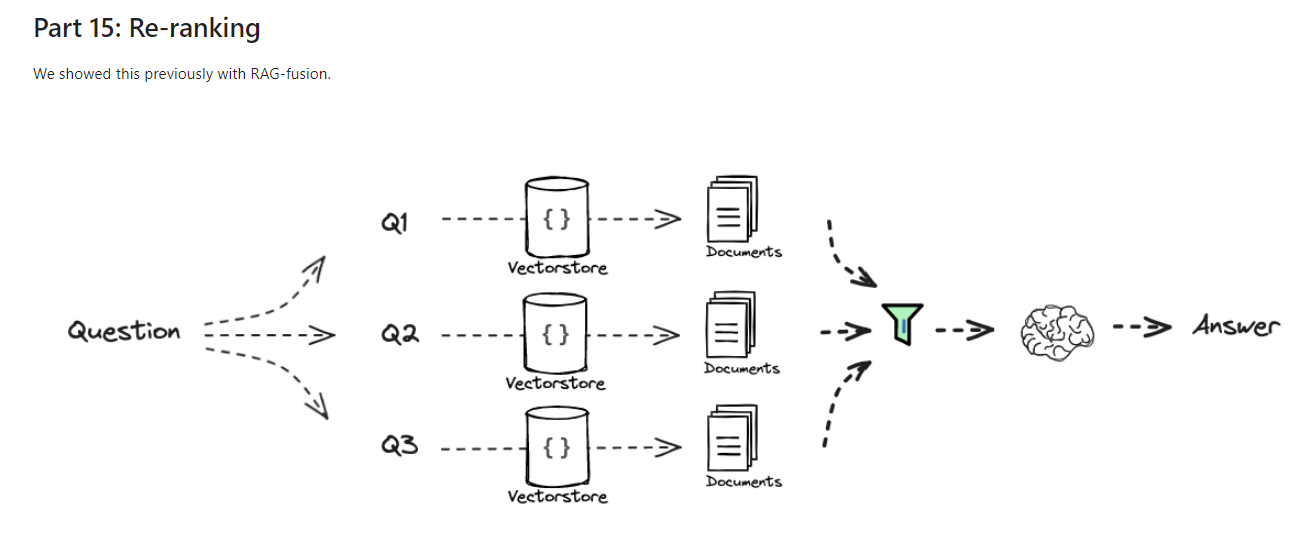

In [1]:
import os
from operator import itemgetter

from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import OpenAIEmbeddings

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

embedding_model = OpenAIEmbeddings(
    openai_api_base="https://openrouter.ai/api/v1",
    model="openai/text-embedding-3-large",
    openai_api_key=OPENROUTER_API_KEY
)

vector_store = Chroma(
    collection_name="basic-rag-overview",
    persist_directory="./chroma_db",
    embedding_function=embedding_model,
)

retriever = vector_store.as_retriever(search_kwargs={"k": 20})
retriever.invoke("What is LBW in cricket?")

[Document(id='3679833e-5050-41dc-8410-f2b07f930c5c', metadata={'summary': 'This is a general glossary of the terminology used in the sport of cricket. Where words in a sentence are also defined elsewhere in this article, they appear in italics. Certain aspects of cricket terminology are explained in more detail in cricket statistics and the naming of fielding positions is explained at fielding (cricket).\nCricket is known for its rich terminology. Some terms are often thought to be arcane and humorous by those not familiar with the game.', 'title': 'Glossary of cricket terms', 'source': 'https://en.wikipedia.org/wiki/Glossary_of_cricket_terms'}, page_content='LBW\nsee leg before wicket\n\nLeading edge\nThe ball hitting the front edge of the bat as opposed to its face, when playing a straight-bat shot. Often results in an easy catch for the bowler or a skier for someone else.\n\nLeave\nThe action of the batter not attempting to play at the ball. They may do this by holding the bat above

In [2]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    input_variables=["question"],
    template="We are creating a RAG with multi-query and reranking. Rewrite the following question into 3 different variations of itself to give different perspectives to the question: {question}. Provide each question in a separate line and do not include any other text in your response."
)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.8, reasoning_format="hidden")

# This breaks the user question to 3 different variations of itself to give different perspectives to the question.
generate_question_pipeline = prompt_template | llm | StrOutputParser() | (
    lambda x: [q.strip() for q in x.splitlines() if q.strip()])

generate_question_pipeline.invoke({"question": "List all the major rules of cricket?"})


['What are the key rules governing cricket?',
 'Can you outline the principal regulations of the game of cricket?',
 "Could you provide a comprehensive list of cricket's major rules?"]

In [3]:
from langchain_core.runnables import RunnableLambda
from langchain_community.document_compressors import JinaRerank
from IPython.display import Markdown

prompt_template_llm = PromptTemplate(
    input_variables=["context", "question"],
    template="""Answer the following question based on the retrieved documents. If the answer is not present in the documents, say 'I don't know'.
    Output: Well formatted answer in markdown format.
        Context: {context}
        Question: {question}
    """
)

reranker = JinaRerank(model="jina-reranker-v3", top_n=20)


def deduplicate(documents: list[list]) -> list:
    seen = set()
    pooled = []
    for docs in documents:
        for doc in docs:
            if doc.page_content not in seen:
                seen.add(doc.page_content)
                pooled.append(doc)
    print(f"Pooled unique documents: {len(pooled)}")
    return pooled


def rerank(inputs: dict) -> str:
    """Rerank pooled docs against the ORIGINAL question, keep top_n, join to text."""
    reranked = reranker.compress_documents(inputs["docs"], inputs["question"])
    print(f"Reranked down to: {len(reranked)}")
    return "\n\n".join(doc.page_content for doc in reranked)


context_chain = (
        {
            "question": itemgetter("question"),
            "docs": itemgetter("question") | generate_question_pipeline | retriever.map() | deduplicate
        }
        | RunnableLambda(rerank)
)

chain = (
        {
            "question": itemgetter("question"),
            "context": context_chain,
        }
        | prompt_template_llm
        | llm
        | StrOutputParser()
)

Markdown(chain.invoke({"question": "List all ICC tournaments in cricket?"}))

C:\Users\verma\AppData\Local\Temp\ipykernel_19760\1330929666.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_compressors import JinaRerank


Pooled unique documents: 34
Reranked down to: 20


**ICC‑organised cricket tournaments mentioned in the supplied documents**

| Category | Tournament (as named in the text) |
|----------|-----------------------------------|
| **One‑Day International (ODI) competitions** | • **ICC Men's Cricket World Cup** (quadrennial world championship)  <br>• **ICC Champions Trophy** (knock‑out ODI event) <br>• **ICC Cricket World Cup Super League** (league competition for ODIs, launched in Aug 2020) |
| **Twenty‑20 (T20) competitions** | • **ICC T20 World Cup** (formerly *ICC World Twenty20*) – held every two years, except when it clashes with the ODI World Cup <br>• **ICC World Twenty20 Qualifier** – qualifying tournament for the T20 World Cup (first held in Dec 2007) |
| **Test cricket competition** | • **ICC World Test Championship** – league competition for Test series (first edition began in 2019) |
| **Associate‑member tournaments** | • **ICC Intercontinental Cup** – first‑class (multi‑day) competition for associate nations <br>• **World Cricket League** – one‑day competition for associate members (also used as the ICC World Cup Qualifier) |
| **One‑off / special events** | • **ICC World Cricket Tsunami Appeal** – a single match (2004/05) <br>• **ICC Super Series** – three‑ODI series (2005/06) |
| **Other ICC‑run competitions** | • **ICC World Cup Qualifier** – the final qualifying tournament for the ICC Men’s Cricket World Cup (derived from the World Cricket League) |

*Note:* The documents also refer to historical or ancillary events (e.g., the Afro‑Asia Cup, the Asian Test Championship) that were **not** ICC‑organised tournaments, so they are omitted from the list above.